
# Level 0 -- What Is an Event Log, and Why Should You Care? 🕵️

Before we touch Sensor2EventLog, or any code at all, let's answer a more basic question: **what is process
mining actually trying to do, and what raw material does it need to do it?**

This notebook is deliberately framework-agnostic -- everything here applies whether you end up using
Sensor2EventLog, PM4Py, Celonis, Disco, or a pile of pandas scripts. Think of it as the "why" that makes the
"how" (coming in Level 1) make sense.

By the end you will have:

- pulled apart a **real, publicly available event log** and discovered a real process model from it (yes, in
  this very first notebook)
- looked at a **real IoT/industrial sensor dataset** and seen exactly why it *isn't* an event log
- a mental model of the gap that eventization exists to close

Let's go.



## 1. Processes are everywhere -- you just don't always see the "log"

A **process** is just: a sequence of steps, carried out repeatedly, usually by different people or machines,
towards some goal. You are surrounded by them:

- Making a coffee (grind, tamp, pull espresso, steam milk, pour)
- A hospital emergency room visit (triage, examination, tests, diagnosis, treatment, discharge)
- Your food delivery order (placed, confirmed, prepared, picked up, delivered)
- A loan application at a bank (submitted, checked, offer sent, accepted, paid out)
- A batch of product moving through a factory (fill, heat, hold, cool, discharge)

Every single one of these, if someone recorded *when* each step happened and *for which specific instance*
(which coffee, which patient, which loan), would give you an event log.

**🧠 Quick check -- which of these produce an event log "for free", just by existing?**

<details>
<summary>Think about it, then click to compare notes</summary>

Almost none of them, actually -- and that's the whole point of this notebook! A hospital's electronic health
record system *does* usually log timestamped steps automatically. A bank's loan system usually does too. But
your home coffee machine almost certainly doesn't write down when you pulled each shot -- even though it is,
absolutely, a process. **Whether a process leaves behind an event log depends entirely on whether something was
built to record it that way.** Industrial sensors are a particularly interesting case: they record enormous
amounts of *something*, but as we'll see in a moment, not the thing process mining actually needs.
</details>



## 2. Meet a real event log

Rather than a toy example, let's use a real one -- the small "running example" dataset that ships with
[PM4Py](https://processintelligence.solutions/pm4py) (the leading open-source process mining library) and that
appears throughout Wil van der Aalst's process mining textbook. It's a handful of insurance/repair claim cases
being handled by a small team.

We'll load it straight from PM4Py's public GitHub repository -- no download needed.


In [1]:

import pandas as pd

url = "https://raw.githubusercontent.com/process-intelligence-solutions/pm4py/release/tests/input_data/running-example.csv"
log_df = pd.read_csv(url)
log_df = log_df[["case:concept:name", "concept:name", "org:resource", "time:timestamp", "Costs"]]
log_df.columns = ["case_id", "activity", "resource", "timestamp", "cost"]

print(f"{log_df['case_id'].nunique()} cases, {len(log_df)} events")
log_df.sort_values(["case_id", "timestamp"]).head(9)


6 cases, 42 events


,case_id,activity,resource,timestamp,cost
14,1,register request,Pete,2010-12-30 11:02:00+01:00,50
15,1,examine thoroughly,Sue,2010-12-31 10:06:00+01:00,400
16,1,check ticket,Mike,2011-01-05 15:12:00+01:00,100
17,1,decide,Sara,2011-01-06 11:18:00+01:00,200
18,1,reject request,Pete,2011-01-07 14:24:00+01:00,200
9,2,register request,Mike,2010-12-30 11:32:00+01:00,50
10,2,check ticket,Mike,2010-12-30 12:12:00+01:00,100
11,2,examine casually,Sean,2010-12-30 14:16:00+01:00,400
12,2,decide,Sara,2011-01-05 11:22:00+01:00,200



Look at case `3` in the output above: `register request` -> `examine casually` -> `check ticket` -> `decide` ->
`reinitiate request` -> `examine thoroughly` -> ... -- a claim that got bounced back for a closer look before
being resolved. That is a genuine, messy, real business process, captured perfectly by three columns:
**who** (`case_id`), **what** (`activity`), **when** (`timestamp`).

Let's not just look at it -- let's actually *do* process mining with it, right now, in four lines:




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




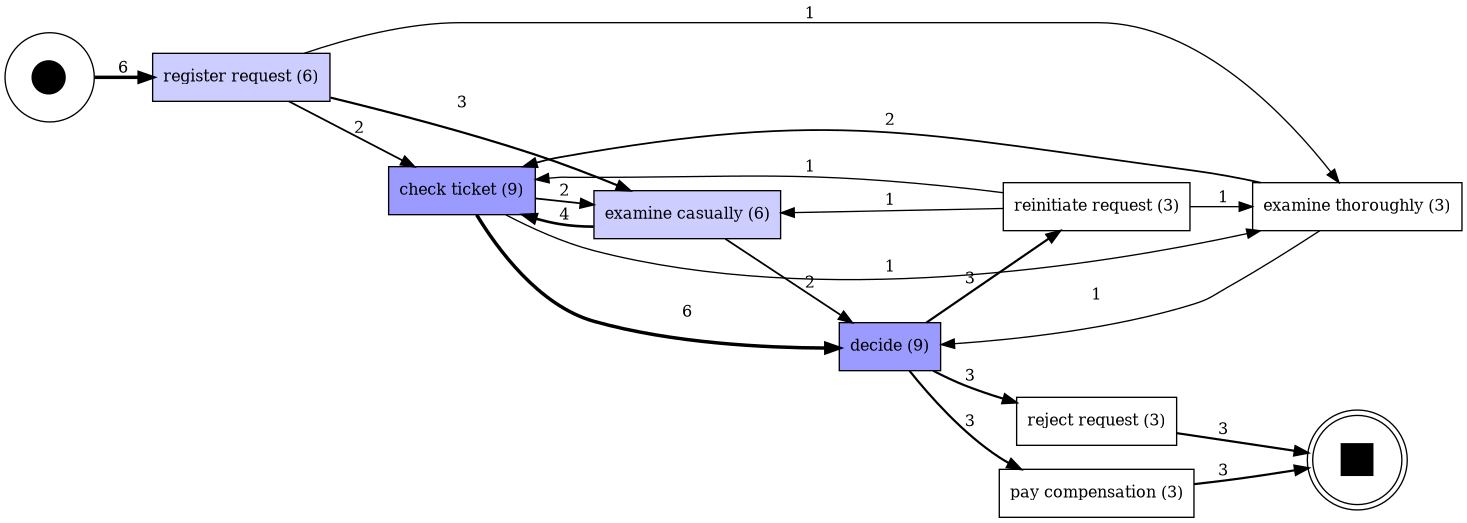

In [2]:

import pm4py

pm4py_log = pm4py.format_dataframe(
    log_df.rename(columns={"case_id": "case:concept:name", "activity": "concept:name", "timestamp": "time:timestamp"}),
    case_id="case:concept:name", activity_key="concept:name", timestamp_key="time:timestamp",
)
dfg, start_activities, end_activities = pm4py.discover_dfg(
    pm4py_log, case_id_key="case:concept:name", activity_key="concept:name", timestamp_key="time:timestamp"
)
pm4py.view_dfg(dfg, start_activities, end_activities, format="png")



That diagram -- arrows sized by how often each transition happens -- was **discovered automatically** from six
cases. Nobody drew it by hand. This is what all of process mining is downstream of: give the algorithm a table
shaped like `(case, activity, timestamp)`, and it can discover the process model, spot bottlenecks, check
whether reality matches a reference model, and much more.

**🧠 Quick check -- what would happen if we *removed* the `case_id` column and just kept `activity` and
`timestamp`?**

<details>
<summary>Click to check your reasoning</summary>

You could still sort everything by time and get *a* sequence of activities -- but you'd have no way to tell
where one case ends and the next begins. `register request` for case 3 and `register request` for case 2 would
become indistinguishable. The DFG discovered above would turn into nonsense, because it would "discover"
transitions between events from completely unrelated cases that simply happened to occur one after another in
time. **Case identity is just as essential as timestamps** -- it's easy to forget this until it's missing.
</details>



## 3. Now let's look at what a sensor actually gives you

That CSV we just used didn't fall from the sky -- someone (or some IT system) already did the work of deciding
what counts as an "activity" and wrote it down that way. Most of the physical world does not come to you
pre-labeled like that.

Here's a real example of the alternative. This dataset simulates realistic IoT sensor readings from industrial
machines -- temperature, vibration, humidity, pressure, energy consumption -- sampled every minute:

> 📊 **[Smart Manufacturing IoT-Cloud Monitoring Dataset](https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset)**
> (Kaggle) -- 100,000 sensor records from 50 machines, one row per minute per machine.

Take a look at the column list on that page. You'll find `Temperature`, `Vibration`, `Humidity`, `Pressure`,
`Energy_Consumption`, a rough `Machine_Status` (Idle / Running / Failure) -- but nothing resembling the clean,
discrete `activity` column we had two cells ago. Instead of "register request" or "check ticket", you get a
number every 60 seconds, forever.


In [3]:

# We don't need to download the full 100k-row dataset to see the shape of the problem --
# here's a small, representative slice of what a real industrial sensor stream looks like:
sensor_sample = pd.DataFrame({
    "machine_id": ["M01"] * 6,
    "timestamp":  pd.date_range("2026-01-01 08:00", periods=6, freq="min"),
    "temperature_c": [24.1, 24.3, 24.0, 30.8, 41.2, 55.6],
    "vibration_mm_s": [0.02, 0.02, 0.03, 0.04, 0.06, 0.05],
    "flow_in": [0.00, 0.00, 0.76, 0.34, 0.36, 0.20],
})
sensor_sample


,machine_id,timestamp,temperature_c,vibration_mm_s,flow_in
0,M01,2026-01-01 08:00:00,24.1,0.02,0.00
1,M01,2026-01-01 08:01:00,24.3,0.02,0.00
2,M01,2026-01-01 08:02:00,24.0,0.03,0.76
3,M01,2026-01-01 08:03:00,30.8,0.04,0.34
4,M01,2026-01-01 08:04:00,41.2,0.06,0.36
5,M01,2026-01-01 08:05:00,55.6,0.05,0.20



No `activity` column. No obvious case boundary beyond `machine_id`. A temperature of 41.2°C doesn't *say*
"we just entered the heating phase" -- a human engineer knows that, but the data itself stays silent about it.

Here's roughly what generated that kind of stream in the real world -- a dairy pasteurization vat, instrumented
with exactly this sort of temperature and flow sensor:

![A stainless steel milk vat used for pasteurization](https://commons.wikimedia.org/wiki/Special:FilePath/Milk_Vat.jpg)

*Milk vat photo: Wikimedia Commons (public domain).*

And the sensor readings from a vat like this one ultimately get collected into a control room like this one --
this is a real water-treatment SCADA (Supervisory Control and Data Acquisition) room, the kind of system that
sits between physical sensors and the historian database an eventization pipeline would eventually read from:

![A real SCADA control room with monitoring screens](https://commons.wikimedia.org/wiki/Special:FilePath/NEWater%20S.C.A.D.A.%20room.jpg)

*SCADA control room photo: Wikimedia Commons (CC BY-SA).*



## 4. Naming the gap

Formally:

| | Event log (Section 2) | Sensor stream (Section 3) |
|---|---|---|
| **What each row represents** | A discrete, named activity | A continuous numeric measurement |
| **Vocabulary** | Symbolic ("check ticket", "decide") | Sub-symbolic (41.2, 0.34, 0.06) |
| **Sampling** | Only when something happens | Constantly, on a fixed clock |
| **Case boundary** | Explicit `case_id` | Sometimes present (e.g. `machine_id`, `batch_id`), sometimes not |

This mismatch is what the process-mining literature calls the **eventization gap**, and closing it -- turning
a continuous stream into a trustworthy `(case, activity, timestamp)` table -- is a research problem in its own
right, not a footnote. Two tempting shortcuts, and why people usually regret them:

- **Hand-written thresholds** ("if temperature > 70, we're in the Hold phase") are transparent, but they don't
  scale past a handful of states, and every new process variant means rewriting rules from scratch.
- **An end-to-end black-box classifier** can scale, but nobody can audit *why* it labeled a given minute "Hold"
  rather than "HeatUp" -- a real problem in regulated industries like food and pharma manufacturing, where you
  may need to justify that label to an auditor.

The family of methods that avoids both traps -- keeping a human expert genuinely in the loop while still
scaling past hand-written rules -- is sometimes called **Machine Teaching**. That's exactly the idea
Sensor2EventLog is built around, and it's where Level 1 picks up.

**🧠 Quick check -- before moving on**

<details>
<summary>Q1: A hospital's IV pump logs a numeric flow rate every 10 seconds. Is that an event log?</summary>

Not yet, by our definition -- it's a sensor stream. It could become the *raw material* for one, though, once
someone (or some algorithm) decides which flow-rate patterns correspond to meaningful clinical events like
"infusion started" or "occlusion detected."
</details>

<details>
<summary>Q2: Your food delivery app shows "Preparing -> Picked up -> On the way -> Delivered." Is that already
an event log?</summary>

Yes! Each of those is a named, discrete activity, timestamped, tied to a specific case (your order ID). This one
required no eventization at all -- the app was built to record it symbolically from the start.
</details>

<details>
<summary>Q3: What's the minimum set of columns an event log needs?</summary>

`case_id`, `activity`, `timestamp` -- everything else (resource, cost, and so on) is a bonus attribute, not a
requirement.
</details>



## 5. Go exploring on your own (optional, but recommended)

A few real, public datasets worth poking at, if you want more practice spotting the difference before Level 1:

**Real event logs (already eventized):**
- [PM4Py running example](https://github.com/process-intelligence-solutions/pm4py/blob/release/tests/input_data/running-example.csv) -- the one we used above.
- [BPI Challenge 2017](https://data.4tu.nl/articles/dataset/BPI_Challenge_2017/12696884) -- a real Dutch bank's loan
  application process, ~1.2M events. Free to download for research/educational use (check the dataset's license
  page for current terms).
- [BPI Challenge 2012](https://data.4tu.nl/articles/dataset/BPI_Challenge_2012/12689204) -- a similar loan process,
  smaller and easier to explore first.

**Real sensor data (not yet eventized):**
- [Smart Manufacturing IoT-Cloud Monitoring Dataset](https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset) --
  used above.
- Search Kaggle for "predictive maintenance sensor" for several similar industrial time-series datasets.

**Try this:** open one event log and one sensor dataset side by side, and for each, write down (a) what the
case_id is or would be, (b) whether "activity" already exists or would need to be invented, and (c) roughly how
often rows arrive. That habit -- always asking those three questions of a new dataset -- is the single most
useful thing in this notebook.



## 6. Recap, and what's next

- A **process** is just repeated steps towards a goal -- it's everywhere, whether or not it's being recorded.
- An **event log** is the specific, minimal shape process mining needs: `(case_id, activity, timestamp)`.
- **Sensor streams** are a different shape entirely: continuous, unlabeled, densely sampled -- and turning one
  into the other (**eventization**) is real, nontrivial work.
- Hand-written rules and black-box models are both tempting shortcuts with real downsides; **Machine
  Teaching** -- keeping a human expert in the loop with structured tools rather than either extreme -- is the
  approach this tutorial series builds towards.

### Where this tutorial series goes from here

This is **Level 0** of a tiered series (matching the table in the project [README](../../README.md)):

| Level | Notebook | What it covers |
|---|---|---|
| 0 | *You are here* | Event logs vs. sensor streams, in general -- no Sensor2EventLog yet |
| 1 | `tutorial/toy_walkthrough.ipynb` | Your first hands-on run of Sensor2EventLog, end to end |
| 1.5 | `tutorials/level_1_5_first_event_log/` | Build your own event log from a CSV with 2-3 rules |
| 2 | `tutorials/level_2_*` | The Machine Teaching loop, supervised vs. unsupervised HMMs, the event-predicate DSL -- each in depth |
| 3 | `tutorials/level_3_*` | The real pasteurization case, eventization-quality evaluation, full PM4Py integration |

Head to **Level 1** next to get hands-on with Sensor2EventLog itself.
